Tied weights means mirroring weights on encoder and decoder side. As we would put mirror in latent layer, our weights are EXACTLY reproduced on decoder side.

In Theory we force the decoder weights to equal the encoder weights. In practice we have only one set of weights and re-use them for encoding and decoding.

In Practice we have only one set of weights and re-use then for encoding and decoding.

In [62]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

/tmp/ipython-input-2247113016.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


# An aside on Linear vs. Parameter classes

In [63]:
x = torch.rand(10,50)
W1 = nn.Parameter(torch.randn(128,50))

# Let's see what W1 is
W1, W1.shape, W1.t().shape

(Parameter containing:
 tensor([[-0.9640, -0.1067,  0.1500,  ..., -0.0140,  2.1319,  0.4923],
         [ 1.1267,  0.2369, -1.3941,  ...,  1.4274,  0.0927, -1.4148],
         [-0.4134, -0.2397, -0.6308,  ..., -0.9138, -1.3497,  2.3596],
         ...,
         [-1.5050, -0.3340,  0.2420,  ..., -0.9885, -1.3375,  0.4602],
         [ 2.3960, -0.8782,  1.2735,  ...,  0.4824,  1.3070,  0.1234],
         [-0.0721,  1.1316,  0.9501,  ..., -0.0402, -0.0461,  0.9206]],
        requires_grad=True),
 torch.Size([128, 50]),
 torch.Size([50, 128]))

In [64]:
W1.t().shape

torch.Size([50, 128])

In [65]:
# compute an output
y = x@W1.t()
y.shape

torch.Size([10, 128])

In [66]:
# Now try again with the Linear method
W2 = nn.Linear(128,50)

# Let's see what W2 is
W2, W2.weight.shape, W2.weight.t().shape

(Linear(in_features=128, out_features=50, bias=True),
 torch.Size([50, 128]),
 torch.Size([128, 50]))

In [67]:
W1.shape, W2.weight.shape

(torch.Size([128, 50]), torch.Size([50, 128]))

size of W $\rightarrow [\text{outputs, inputs}]$, but nn.Linear expects [inputs, outputs]$

In [68]:
# see all attributes of the class Linear
dir(nn.Linear)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__constants__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_call_impl',
 '_compiled_call_impl',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_load_from_state_dict',
 '_maybe_warn_non_full_backward_hook',
 '_named_members',
 '_register_load_state_dict_pre_hook',
 '_register_state_dict_hook',
 '_replicate_for_data_parallel',
 '_save_to_state_dict',
 '_slow_forward',
 '_version',
 '_wrapped_call_impl',
 'add_module',
 'apply',
 'bfloat16',
 'buffers',
 'call_super_init',
 'children',
 'compile',
 'cpu',
 'cuda',
 'double',
 'dump_p

# Data

In [69]:
# import dataset (comes with colab)
data = np.loadtxt(open('sample_data/mnist_train_small.csv','rb'), delimiter = ',')

# don't need labels
data = data[:,1:]

# normalize
data_norm = data / np.max(data)

# convert to tensor
data_t = torch.tensor(data_norm).float()
data_t

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

# Model

In [70]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.inp = nn.Linear(784, 128)

    self.enc = nn.Parameter(torch.randn(50,128))

    self.dec = nn.Linear(128, 784)

  def forward(self, x):

    x = F.relu(self.inp(x))

    x = x.t()
    x = F.relu(self.enc@x)

    x = F.relu(self.enc.t()@x)
    x = x.t()

    y = torch.sigmoid(self.dec(x))
    return y

In [71]:
net = Net()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters(), lr = .001)

# Train

In [75]:
def ModelTrain(epochs, verbose):
  losses = torch.zeros(epochs)

  for epoch in range(epochs):
    random_idxs = np.random.choice(data_t.shape[0], 32, replace = False)
    x = torch.tensor(data_t[random_idxs, :], dtype = torch.float)

    x_hat = net(x)
    loss = loss_fn(x_hat, x)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses[epoch] = loss.item()

    if verbose and epoch%100 == 0:
      print(f'Epoch: {epoch} | Loss: {losses[epoch]:.2f}')

  return losses, net

In [77]:
losses, net = ModelTrain(epochs = 10000, verbose = True)

/tmp/ipython-input-1693064945.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(data_t[random_idxs, :], dtype = torch.float)


Epoch: 0 | Loss: 0.15
Epoch: 100 | Loss: 0.15
Epoch: 200 | Loss: 0.13
Epoch: 300 | Loss: 0.13
Epoch: 400 | Loss: 0.14
Epoch: 500 | Loss: 0.13
Epoch: 600 | Loss: 0.13
Epoch: 700 | Loss: 0.13
Epoch: 800 | Loss: 0.11
Epoch: 900 | Loss: 0.11
Epoch: 1000 | Loss: 0.11
Epoch: 1100 | Loss: 0.11
Epoch: 1200 | Loss: 0.10
Epoch: 1300 | Loss: 0.09
Epoch: 1400 | Loss: 0.10
Epoch: 1500 | Loss: 0.10
Epoch: 1600 | Loss: 0.09
Epoch: 1700 | Loss: 0.09
Epoch: 1800 | Loss: 0.09
Epoch: 1900 | Loss: 0.09
Epoch: 2000 | Loss: 0.09
Epoch: 2100 | Loss: 0.09
Epoch: 2200 | Loss: 0.08
Epoch: 2300 | Loss: 0.08
Epoch: 2400 | Loss: 0.09
Epoch: 2500 | Loss: 0.08
Epoch: 2600 | Loss: 0.09
Epoch: 2700 | Loss: 0.08
Epoch: 2800 | Loss: 0.08
Epoch: 2900 | Loss: 0.08
Epoch: 3000 | Loss: 0.08
Epoch: 3100 | Loss: 0.08
Epoch: 3200 | Loss: 0.07
Epoch: 3300 | Loss: 0.07
Epoch: 3400 | Loss: 0.07
Epoch: 3500 | Loss: 0.08
Epoch: 3600 | Loss: 0.06
Epoch: 3700 | Loss: 0.07
Epoch: 3800 | Loss: 0.08
Epoch: 3900 | Loss: 0.07
Epoch: 4000 

# Viz

## Loss

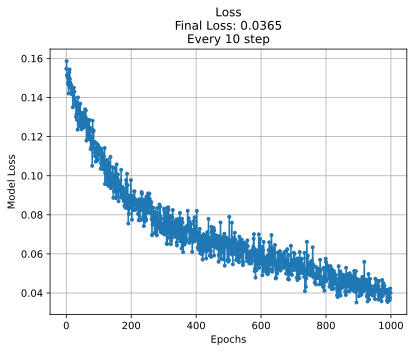

In [89]:
step = 10
plt.plot(losses[::step], '.-')
plt.xlabel('Epochs')
plt.ylabel('Model Loss')
plt.title(f'Loss\nFinal Loss: {losses[-1]:.4f}\nEvery {step} step')
plt.grid()
plt.show()

## Modelled

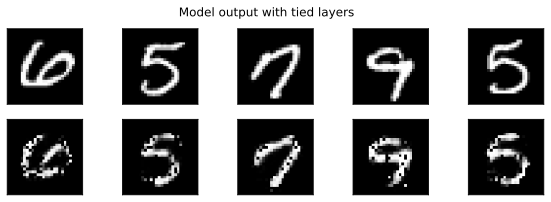

In [92]:
X = data_t[:5,:]
y_hat = net(X)

fig, axs = plt.subplots(2,5,figsize = (10,3))

for i in range(5):
  axs[0, i].imshow(X[i,:].view(28,28).detach(), cmap = 'gray')
  axs[1, i].imshow(y_hat[i,:].view(28,28).detach(), cmap = 'gray')
  axs[0,i].set_xticks([]), axs[0,i].set_yticks([])
  axs[1,i].set_xticks([]), axs[1,i].set_yticks([])

plt.suptitle('Model output with tied layers')
plt.show()

## With Noise

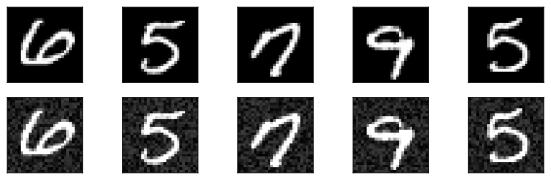

In [99]:
X = data_t[:10,:]

# add noise
X_noise = X + torch.rand_like(X)/4

# clip at 1
X_noise[X_noise>1] = 1

# show the noisy images
fig, axs = plt.subplots(2,5,figsize=(10,3))

for i in range(5):
  axs[0,i].imshow(X[i,:].view(28,28).detach(), cmap = 'gray')
  axs[1,i].imshow(X_noise[i,:].view(28,28).detach(), cmap = 'gray')
  axs[0,i].set_xticks([]), axs[0,i].set_yticks([])
  axs[1,i].set_xticks([]), axs[1,i].set_yticks([])

plt.show()

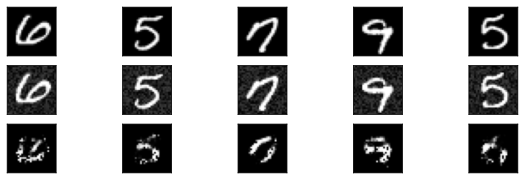

In [103]:
Y = net(X_noise)

# show the noisy images
fig, axs = plt.subplots(3,5,figsize=(10,3))

for i in range(5):
  axs[0,i].imshow(X[i,:].view(28,28).detach(), cmap = 'gray')
  axs[1,i].imshow(X_noise[i,:].view(28,28).detach(), cmap = 'gray')
  axs[2,i].imshow(Y[i,:].view(28,28).detach(), cmap = 'gray')
  axs[0,i].set_xticks([]), axs[0,i].set_yticks([])
  axs[1,i].set_xticks([]), axs[1,i].set_yticks([])
  axs[2,i].set_xticks([]), axs[2,i].set_yticks([])

plt.show()

Noise disappeared indeed, but denoising destroyed the image. Our model wasn't able to denoise maintaining actual shape of the number.